# Sistema de Detección de Billetes Falsos Usando Aprendizaje Profundo (Red Neuronal Artificial - ANN)

Lucho Oct | 2022 <br>
Coconut by Harry Nilsson

## 📊 Acerca de los Datos

Los datos fueron extraídos de imágenes tomadas para evaluar un procedimiento de autenticación de billetes.  
Se utilizaron imágenes de ejemplares de billetes **auténticos** y **falsificados**.

Para la digitalización, se empleó una **cámara industrial** comúnmente utilizada para inspección de impresiones.  
Las imágenes finales tienen una resolución de **400 x 400 píxeles**.  
Debido al lente del objetivo y la distancia al objeto examinado, se obtuvieron imágenes en **escala de grises** con una resolución de aproximadamente **660 dpi**.

Se utilizó una herramienta de **Transformada Wavelet** para extraer características de las imágenes.

---

## 📄 Descripción de los Datos

| Variable | Descripción |
|----------|-------------|
| `VWTI`   | Varianza de la Imagen Transformada por Wavelet |
| `SWTI`   | Asimetría (Skewness) de la Imagen Transformada por Wavelet |
| `CWTI`   | Curtosis de la Imagen Transformada por Wavelet |
| `EI`     | Entropía de la Imagen |
| `Class`  | Clase (1: auténtico, 0: falsificado) |

---

Dataset: https://www.kaggle.com/datasets/gauravduttakiit/banknote/data

## Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

import pickle

## Import Datasets

In [2]:
df = pd.read_csv("train.csv")
data = df.copy()
data.head()

,VWTI,SWTI,CWTI,EI,Class
0,2.2634,-4.4862,3.6558,-0.612510,0
1,3.2718,1.7837,2.1161,0.613340,0
2,-3.9411,-12.8792,13.0597,-3.312500,1
3,0.5195,-3.2633,3.0895,-0.984900,0
4,2.5698,-4.4076,5.9856,0.078002,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   VWTI    1096 non-null   float64
 1   SWTI    1096 non-null   float64
 2   CWTI    1096 non-null   float64
 3   EI      1096 non-null   float64
 4   Class   1096 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 42.9 KB


In [4]:
data.describe()

,VWTI,SWTI,CWTI,EI,Class
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,0.448500,1.780643,1.493533,-1.157454,0.445255
std,2.852623,5.922621,4.375655,2.084983,0.497221
min,-7.036400,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.790850,-2.125200,-1.574975,-2.246975,0.000000
50%,0.540430,2.205850,0.671900,-0.569190,0.000000
75%,2.835350,6.793925,3.574450,0.399980,1.000000
max,6.563300,12.730200,17.927400,2.449500,1.000000


In [5]:
data.columns

Index(['VWTI', 'SWTI', 'CWTI', 'EI', 'Class'], dtype='object')

In [6]:
data.shape

(1096, 5)

In [7]:
df.isna().sum()

VWTI     0
SWTI     0
CWTI     0
EI       0
Class    0
dtype: int64

In [8]:
data.duplicated().sum()

17

In [9]:
data = data.drop_duplicates()

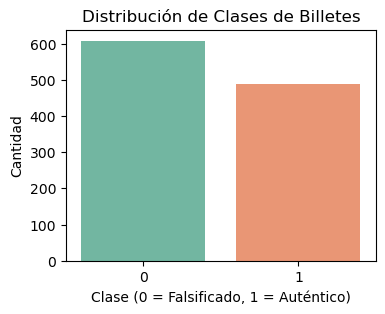

In [10]:
# Conteo de clases 
plt.figure(figsize=(4, 3))
sns.countplot(x='Class', hue='Class', data=df, palette='Set2', legend=False)
plt.title('Distribución de Clases de Billetes')
plt.xlabel('Clase (0 = Falsificado, 1 = Auténtico)')
plt.ylabel('Cantidad')
plt.show()

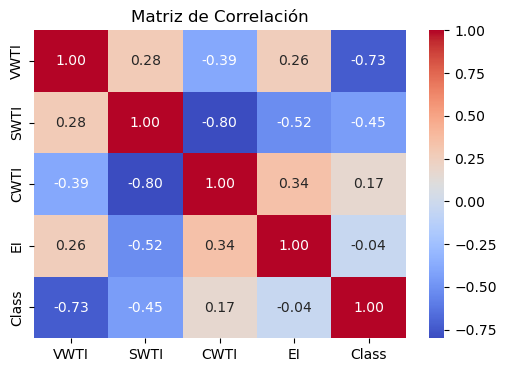

In [11]:
# Mapa de calor de correlaciones
plt.figure(figsize=(6, 4))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

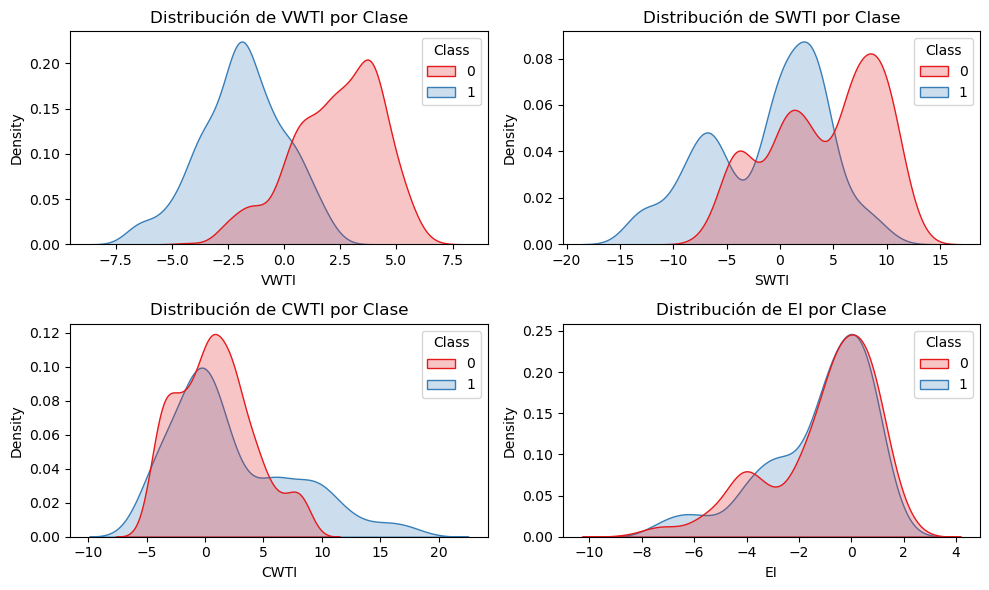

In [12]:
# Relación entre características e identificación de clase
plt.figure(figsize=(10, 6))
for i, col in enumerate(['VWTI', 'SWTI', 'CWTI', 'EI']):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(data=df, x=col, hue='Class', fill=True, common_norm=False, palette='Set1')
    plt.title(f'Distribución de {col} por Clase')
plt.tight_layout()
plt.show()

### Preparamiento de los datos

In [13]:
# Separar las características (features) y la variable objetivo (target)
X = data[['VWTI', 'SWTI', 'CWTI', 'EI']]  # Ajustar estas columnas si tu conjunto de datos es diferente
y = data['Class']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dividir aún más los datos de entrenamiento en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Escalar características (normalización)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Asegurar que la variable objetivo esté en formato binario (0 o 1 para clasificación binaria)
# No se necesita codificación one-hot para clasificación binaria
y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

# Verificar las dimensiones de los conjuntos de datos
print(f"Forma de X_train: {X_train.shape}, Forma de y_train: {y_train.shape}")
print(f"Forma de X_val: {X_val.shape}, Forma de y_val: {y_val.shape}")
print(f"Forma de X_test: {X_test.shape}, Forma de y_test: {y_test.shape}")


Forma de X_train: (690, 4), Forma de y_train: (690,)
Forma de X_val: (173, 4), Forma de y_val: (173,)
Forma de X_test: (216, 4), Forma de y_test: (216,)


#### Preparacion de la red

In [14]:
# Definir el modelo 
model = Sequential([
    Input(shape=(X_train.shape[1],)),          # Capa de entrada explícita
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')             # Capa de salida para clasificación binaria
])

# Compilar el modelo
model.compile(
    optimizer='adam',  # Optimizador Adam
    loss='binary_crossentropy',  # Función de pérdida para clasificación binaria
    metrics=['accuracy']  # Métrica de evaluación: precisión
)

# Añadir EarlyStopping para evitar sobreajuste
early_stopping = EarlyStopping(
    monitor='val_loss',           # Monitorea la pérdida en validación
    patience=5,                   # Detiene el entrenamiento si no mejora en 5 épocas
    restore_best_weights=True     # Restaura los pesos del mejor modelo
)

# Mostrar un resumen del modelo
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  # Datos de validación para monitorear el desempeño
    epochs=50,                       # Número máximo de épocas
    batch_size=32,                   # Tamaño del lote (batch)
    callbacks=[early_stopping]       # Utilizar el callback de EarlyStopping
)


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5810 - loss: 0.6583 - val_accuracy: 0.8728 - val_loss: 0.5161
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8060 - loss: 0.5232 - val_accuracy: 0.8902 - val_loss: 0.3788
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8611 - loss: 0.4058 - val_accuracy: 0.9306 - val_loss: 0.2505
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9015 - loss: 0.2846 - val_accuracy: 0.9538 - val_loss: 0.1587
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9628 - loss: 0.1613 - val_accuracy: 0.9827 - val_loss: 0.0969
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9633 - loss: 0.1205 - val_accuracy: 0.9827 - val_loss: 0.0617
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9757 - loss: 0.0800 - val_accuracy: 0.9827 - val_loss: 0.0445
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9796 - loss: 0.0864 - val_accuracy: 0.9827 - val_loss

In [16]:
# Evaluar el modelo en el conjunto de prueba
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Pérdida en test: {test_loss:.4f}, Precisión en test: {test_acc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9925 - loss: 0.0118     
Pérdida en test: 0.0145, Precisión en test: 0.9907


#### Metricas

In [17]:
y_pred = (model.predict(X_test) > 0.5).astype(int)


print("Classification Report:")
print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       117
           1       0.98      1.00      0.99        99

    accuracy                           0.99       216
   macro avg       0.99      0.99      0.99       216
weighted avg       0.99      0.99      0.99       216



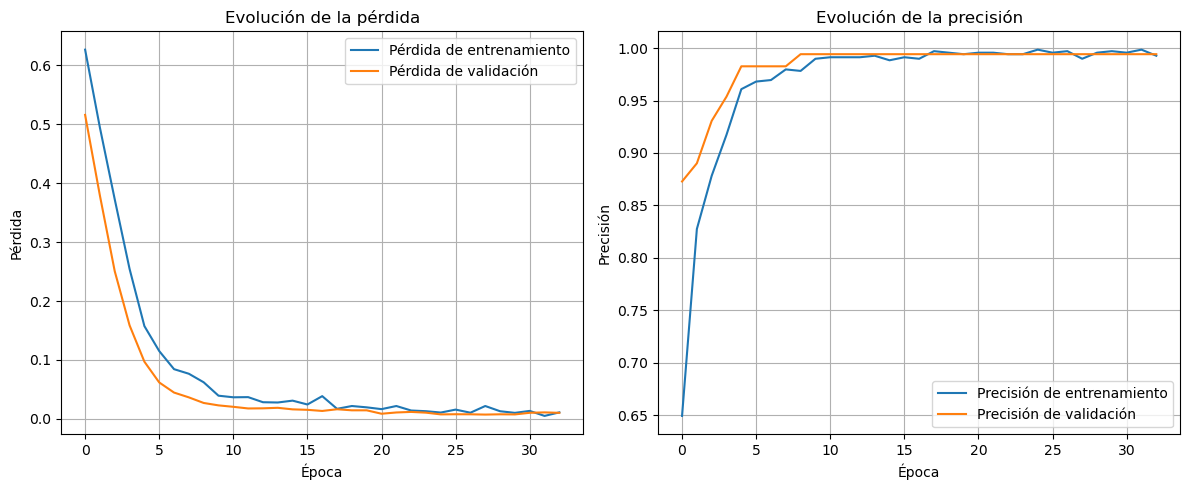

In [18]:
# Gráfico de la pérdida (loss)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico de la precisión (accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.title('Evolución de la precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


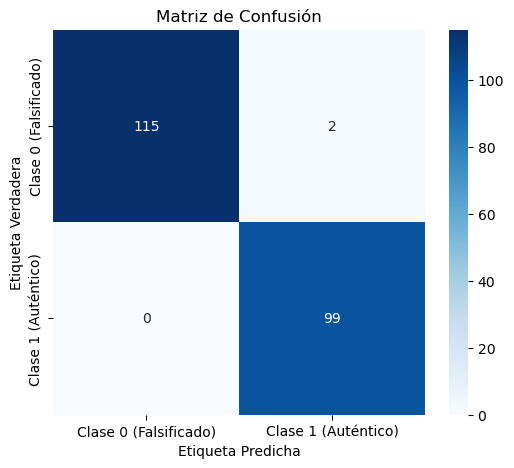

In [19]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Clase 0 (Falsificado)', 'Clase 1 (Auténtico)'],
    yticklabels=['Clase 0 (Falsificado)', 'Clase 1 (Auténtico)']
)

plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()

### Prediccion

In [20]:
# Definir la función hacer_predicción
def hacer_prediccion(datos_entrada):
    # Convertir a DataFrame con nombres de columnas para evitar warnings
    columnas = ['VWTI', 'SWTI', 'CWTI', 'EI']
    datos_entrada_df = pd.DataFrame(datos_entrada, columns=columnas)

    # Escalar los datos
    datos_entrada_escalados = scaler.transform(datos_entrada_df)

    # Hacer la predicción
    predicciones = model.predict(datos_entrada_escalados)
    clases_predichas = (predicciones > 0.5).astype(int)

    # Devolver el resultado
    if clases_predichas[0] == 1:
        return "Auténtico"
    else:
        return "Falsificado"


In [21]:
# Ejemplo de datos de entrada para la predicción (reemplazar con datos reales)
datos_entrada = np.array([[1.5, 2.3, 3.4, 0.7]])  # Datos de ejemplo

# Obtener la predicción
resultado = hacer_prediccion(datos_entrada)
print(resultado)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Falsificado


In [22]:
# Datos de entrada de ejemplo para la predicción
input_data = np.array([[-3.9411, -12.8792,  13.0597,  -3.3125]])  # Datos reales o de prueba

# Obtener la predicción
resultado = hacer_prediccion(input_data)

# Mostrar el resultado
print(resultado)  # Mostrará "Auténtico" o "Falsificado"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Auténtico


### Guardar el modelo

In [23]:
model.save('models/model.h5')
# Save the scaler using pickle
with open('models/scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)